# 🔴 Project - Hard · California Housing with Round-by-Round AdaBoost

> **MLCourse · Machine Learning · supervised · regression**

### Business question
A housing analytics team asks: *how accurately can we value a census block group
from demographics alone, and how does accuracy grow as we add boosting rounds?*
We work on a fixed 6,000-row sample of the real 20,640-block California dataset,
and confront two hard limits: boosting's early-stop behaviour and trees' inability
to extrapolate.

### Inline plotting for Jupyter; plain-Python runs fall through harmlessly.


In [ ]:
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:            # no IPython here -> nothing to wire up
    pass
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.tree import DecisionTreeRegressor
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import AdaBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.random.seed(42)
sns.set_theme()
plt.rcParams["figure.dpi"] = 100

def find_data_dir() -> Path:
    here = Path.cwd()
    for candidate in [here, *here.parents]:        # walk up to the course root
        if candidate.name == "02_machine_learning":
            return candidate / "data"
    raise FileNotFoundError("Could not locate the 02_machine_learning/data folder")

DATA_DIR = find_data_dir()

CAL_CSV = DATA_DIR / "california_housing.csv"
if not CAL_CSV.exists():                            # download-once helper:
    from sklearn.datasets import fetch_california_housing   # cached sklearn copy
    fetch_california_housing(as_frame=True).frame.to_csv(CAL_CSV, index=False)

cal = pd.read_csv(CAL_CSV)
print("full dataset:", cal.shape)
sample = cal.sample(n=6000, random_state=42)        # fixed sample => reproducible project
TARGET = "MedHouseVal"                              # median house value, $100k units
print("working sample:", sample.shape)


### 1. EDA - geography IS the dataset


count    6000.00
mean        2.07
std         1.15
min         0.15
25%         1.20
50%         1.81
75%         2.66
max         5.00
Name: MedHouseVal, dtype: float64


C:\Users\Thoyajaksha Kashyap\AppData\Local\Temp\ipykernel_77448\4257613583.py:16: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()


D:\projects\python\MLCourse\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


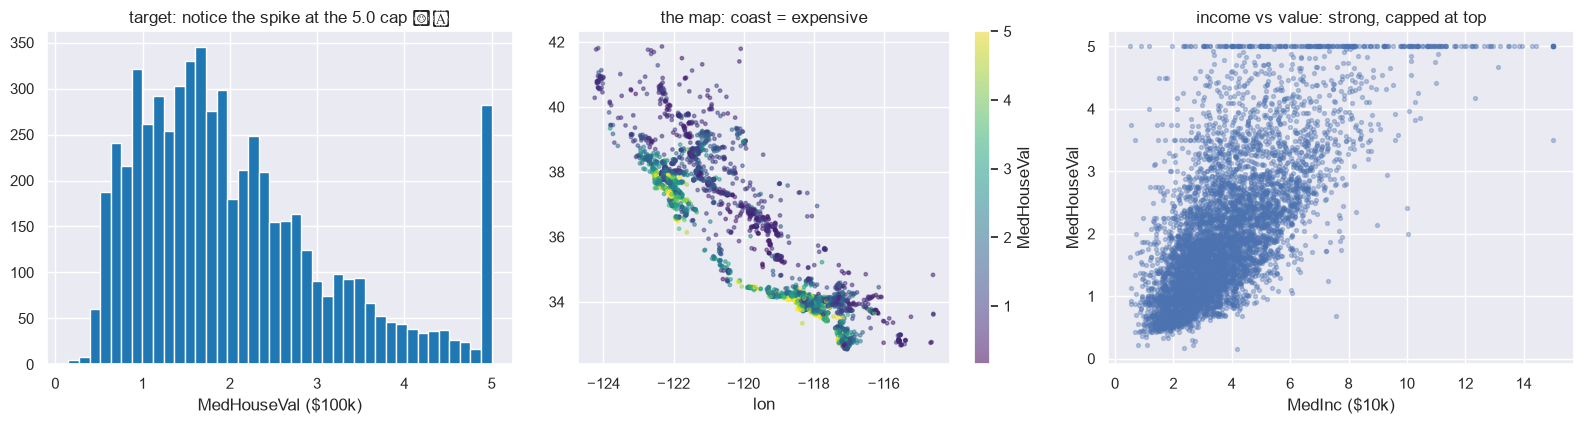

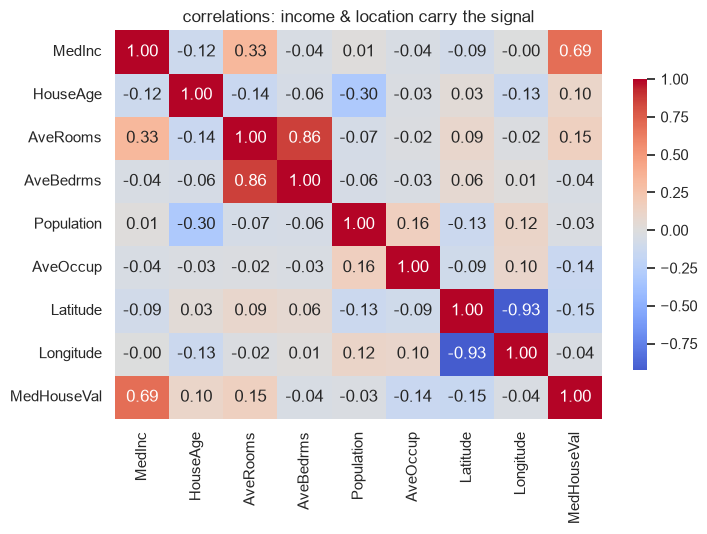

In [2]:
print(sample[TARGET].describe().round(2))
fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))

axes[0].hist(sample[TARGET], bins=40, color="tab:blue", edgecolor="white")
axes[0].set_title("target: notice the spike at the 5.0 cap ⚠️")
axes[0].set_xlabel("MedHouseVal ($100k)")

sc = axes[1].scatter(sample["Longitude"], sample["Latitude"],
                     c=sample[TARGET], s=6, alpha=0.5, cmap="viridis")
plt.colorbar(sc, ax=axes[1], label="MedHouseVal")
axes[1].set_title("the map: coast = expensive"); axes[1].set_xlabel("lon")

axes[2].scatter(sample["MedInc"], sample[TARGET], s=8, alpha=0.35)
axes[2].set_xlabel("MedInc ($10k)"); axes[2].set_ylabel(TARGET)
axes[2].set_title("income vs value: strong, capped at top")
plt.tight_layout(); plt.show()

plt.figure(figsize=(7.5, 5.5))
sns.heatmap(sample.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0,
            cbar_kws={"shrink": 0.75})
plt.title("correlations: income & location carry the signal")
plt.tight_layout(); plt.show()
# ⚠️ That vertical line of dots at target = 5.00001 is REAL: values above ~$500k were
#    capped when the data was built. Models will learn the cap as a hard ceiling.

### 2. Split and baselines


In [3]:
X = sample.drop(columns=[TARGET])
y = sample[TARGET]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42)

def metrics(y_true, pred):
    """One place to compute all reported metrics consistently."""
    return {
        "R²": r2_score(y_true, pred),
        "MAE": mean_absolute_error(y_true, pred),
        "RMSE": mean_squared_error(y_true, pred) ** 0.5,
    }

rows = {}
pred_dummy = np.full(len(y_test), y_train.mean())          # floor: predict train mean
rows["Dummy (mean)"] = metrics(y_test, pred_dummy)
lin = LinearRegression().fit(X_train, y_train)             # linear yardstick
rows["Linear regression"] = metrics(y_test, lin.predict(X_test))
one_tree3 = DecisionTreeRegressor(max_depth=3, random_state=42).fit(X_train, y_train)
rows["Single depth-3 tree"] = metrics(y_test, one_tree3.predict(X_test))
one_tree5 = DecisionTreeRegressor(max_depth=5, random_state=42).fit(X_train, y_train)
rows["Single depth-5 tree"] = metrics(y_test, one_tree5.predict(X_test))
pd.DataFrame(rows).T.round(3)

,R²,MAE,RMSE
Dummy (mean),-0.002,0.917,1.169
Linear regression,0.609,0.531,0.730
Single depth-3 tree,0.519,0.596,0.810
Single depth-5 tree,0.585,0.535,0.752


### 3. Fit once, evaluate EVERY round size ("poor-man's staging")

⚠️ AdaBoost regressor has no `staged_predict`. But its prediction rule is public:
a vote-weighted MEDIAN over the first `k` trees. So we fit ONE 500-round model and
recompute that median for growing `k` - one training run, a full learning curve.

💡 Weakness matters: depth-3 stumps barely beat their own single-tree baseline here,
so we promote the weak learner to depth 5. With `loss="linear"` most rounds would die
early on this hard dataset (round score ≥ 0.5), hence `loss="exponential"`.

In [4]:
ada_full = AdaBoostRegressor(
    estimator=DecisionTreeRegressor(max_depth=5),
    n_estimators=500, learning_rate=0.05, loss="exponential",
    random_state=42,
).fit(X_train, y_train)
n_alive = len(ada_full.estimators_)
print(f"{n_alive} of 500 rounds survived early stopping")
rows[f"AdaBoost ({n_alive} rounds)"] = metrics(y_test, ada_full.predict(X_test))
pd.DataFrame(rows).T.round(3)

500 of 500 rounds survived early stopping


,R²,MAE,RMSE
Dummy (mean),-0.002,0.917,1.169
Linear regression,0.609,0.531,0.730
Single depth-3 tree,0.519,0.596,0.810
Single depth-5 tree,0.585,0.535,0.752
AdaBoost (500 rounds),0.684,0.513,0.656


D:\projects\python\MLCourse\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
D:\projects\python\MLCourse\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
D:\projects\python\MLCourse\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
D:\projects\python\MLCourse\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
D:\projects\python\MLCourse\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
D:\projects\python\M

D:\projects\python\MLCourse\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
D:\projects\python\MLCourse\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
D:\projects\python\MLCourse\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
D:\projects\python\MLCourse\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
D:\projects\python\MLCourse\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
D:\projects\python\M

max |manual − sklearn.predict| = 0.0


D:\projects\python\MLCourse\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
D:\projects\python\MLCourse\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
D:\projects\python\MLCourse\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
D:\projects\python\MLCourse\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
D:\projects\python\MLCourse\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
D:\projects\python\M

D:\projects\python\MLCourse\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
D:\projects\python\MLCourse\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
D:\projects\python\MLCourse\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
D:\projects\python\MLCourse\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
D:\projects\python\MLCourse\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
D:\projects\python\M

...

D:\projects\python\MLCourse\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
D:\projects\python\MLCourse\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
D:\projects\python\MLCourse\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
D:\projects\python\MLCourse\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
D:\projects\python\MLCourse\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
D:\projects\python\M

D:\projects\python\MLCourse\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
D:\projects\python\MLCourse\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
D:\projects\python\MLCourse\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
D:\projects\python\MLCourse\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
D:\projects\python\MLCourse\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
D:\projects\python\M

D:\projects\python\MLCourse\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
D:\projects\python\MLCourse\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
D:\projects\python\MLCourse\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
D:\projects\python\MLCourse\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
D:\projects\python\MLCourse\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
D:\projects\python\M

D:\projects\python\MLCourse\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
D:\projects\python\MLCourse\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
D:\projects\python\MLCourse\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
D:\projects\python\MLCourse\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
D:\projects\python\MLCourse\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
D:\projects\python\M

D:\projects\python\MLCourse\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
D:\projects\python\MLCourse\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
D:\projects\python\MLCourse\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
D:\projects\python\MLCourse\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
D:\projects\python\MLCourse\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
D:\projects\python\M

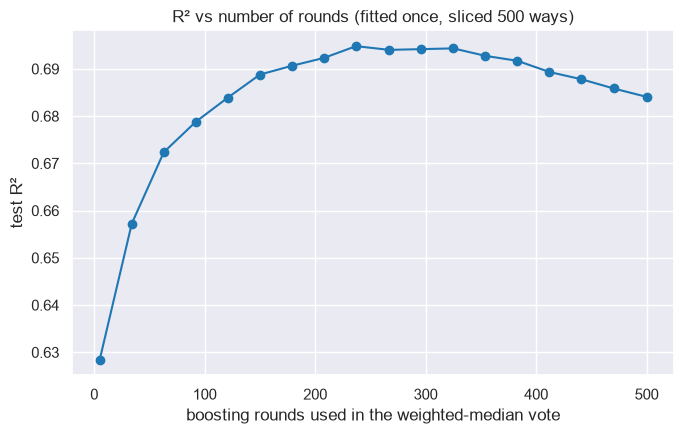

In [5]:
def weighted_median_predict(model, X_eval, limit):
    """Replicate sklearn's prediction using only the first `limit` trees.

    Prediction = per-row median of tree outputs where tree m votes with weight
    estimator_weights_[m]. Re-implemented here because AdaBoostRegressor exposes
    no staged API for regression."""
    ests = model.estimators_[:limit]
    preds = np.column_stack([est.predict(X_eval) for est in ests])  # (n_rows, limit)
    votes = model.estimator_weights_[:limit].astype(float)   # RAW weights - sklearn's
    order = np.argsort(preds, axis=1)                        # _get_median_predict does
    sorted_preds = np.take_along_axis(preds, order, axis=1)  # NOT exponentiate them!
    sorted_votes = votes[order]                              # votes follow along
    cum = np.cumsum(sorted_votes, axis=1)                    # running vote mass
    half = cum[:, -1][:, None] / 2.0                         # halfway mark
    pick = np.argmax(cum >= half, axis=1)                    # first guess past it
    return sorted_preds[np.arange(len(X_eval)), pick]


# sanity: our function at full size must equal sklearn's own predict()
reproduced = weighted_median_predict(ada_full, X_test, n_alive)
print("max |manual - sklearn.predict| =", np.abs(reproduced - ada_full.predict(X_test)).max())

sizes = np.unique(np.linspace(5, n_alive, 18).astype(int))       # 18 checkpoints
curve = [r2_score(y_test, weighted_median_predict(ada_full, X_test, k)) for k in sizes]

plt.figure(figsize=(7, 4.5))
plt.plot(sizes, curve, marker="o", color="tab:blue")
plt.xlabel("boosting rounds used in the weighted-median vote")
plt.ylabel("test R²")
plt.title(f"R² vs number of rounds (fitted once, sliced {n_alive} ways)")
plt.tight_layout(); plt.show()

### 4. Learning-rate race - three separate fits

`learning_rate` shrinks every tree's vote; small steps are safer per-round but may
need more rounds to converge. Three honest refits make the trade-off concrete.

lr=0.05: {'rounds survived': 500, 'R²': 0.6840766235751076, 'MAE': 0.5129818151175118, 'RMSE': 0.6563825669338351}


lr=0.1: {'rounds survived': 500, 'R²': 0.6632298710841835, 'MAE': 0.5485346840641662, 'RMSE': 0.6776929042777033}


lr=0.2: {'rounds survived': 500, 'R²': 0.6381778916309608, 'MAE': 0.5753128711924794, 'RMSE': 0.7024472341469646}


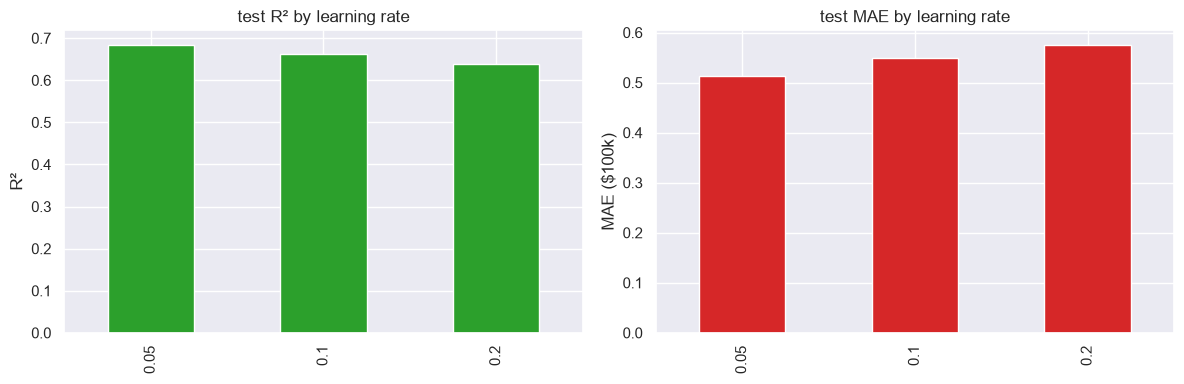

In [6]:
race = {}
for lr in [0.05, 0.1, 0.2]:
    m = AdaBoostRegressor(DecisionTreeRegressor(max_depth=5),
                          n_estimators=500, loss="exponential", learning_rate=lr,
                          random_state=42).fit(X_train, y_train)
    race[lr] = {"rounds survived": len(m.estimators_), **metrics(y_test, m.predict(X_test))}
    print(f"lr={lr}: {race[lr]}")

race_df = pd.DataFrame(race).T
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
race_df["R²"].plot.bar(ax=axes[0], color="tab:green")
axes[0].set_title("test R² by learning rate"); axes[0].set_ylabel("R²")
race_df["MAE"].plot.bar(ax=axes[1], color="tab:red")
axes[1].set_title("test MAE by learning rate"); axes[1].set_ylabel("MAE ($100k)")
plt.tight_layout(); plt.show()

### 5. The extrapolation wall - trees cannot leave the training range

Every weak learner is a step function bounded by leaf means of TRAINING data;
no weighted median of them can escape either. We prove it: train ONLY on blocks
with below-median income, then ask for prices in rich neighbourhoods.

training range of target      : [0.17, 5.00]
richest-decile actual range   : [1.70, 5.00]
predictions for those blocks  : [1.61, 3.18]


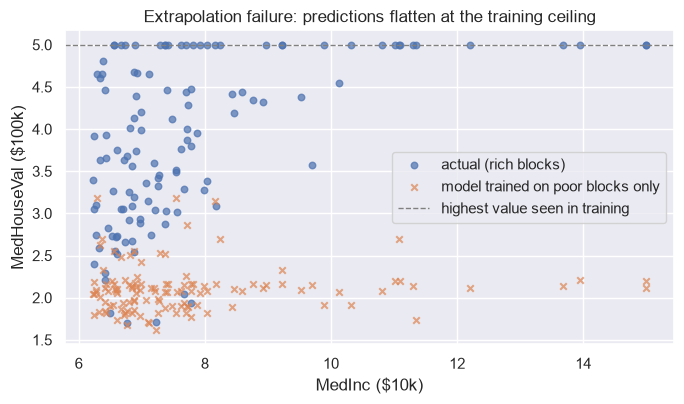

In [7]:
inc_median = X_train["MedInc"].median()                    # split income at its middle
low_mask = X_train["MedInc"] <= inc_median                 # poor-ish blocks only
ada_poor = AdaBoostRegressor(DecisionTreeRegressor(max_depth=5),
                             n_estimators=300, loss="exponential",
                             random_state=42).fit(X_train[low_mask], y_train[low_mask])

rich_mask = X_test["MedInc"] > X_test["MedInc"].quantile(0.90)   # richest decile
rich_pred = ada_poor.predict(X_test[rich_mask])
print(f"training range of target      : [{y_train[low_mask].min():.2f}, "
      f"{y_train[low_mask].max():.2f}]")
print(f"richest-decile actual range   : [{y_test[rich_mask].min():.2f}, "
      f"{y_test[rich_mask].max():.2f}]")
print(f"predictions for those blocks  : [{rich_pred.min():.2f}, {rich_pred.max():.2f}]")

plt.figure(figsize=(7, 4.2))
plt.scatter(X_test.loc[rich_mask, "MedInc"], y_test[rich_mask],
            s=22, alpha=0.7, label="actual (rich blocks)")
plt.scatter(X_test.loc[rich_mask, "MedInc"], rich_pred,
            s=22, alpha=0.7, marker="x", label="model trained on poor blocks only")
plt.axhline(y_train[low_mask].max(), color="gray", ls="--", lw=1,
            label="highest value seen in training")
plt.xlabel("MedInc ($10k)"); plt.ylabel("MedHouseVal ($100k)")
plt.title("Extrapolation failure: predictions flatten at the training ceiling")
plt.legend(); plt.tight_layout(); plt.show()

### 6. Final diagnostics on the main model


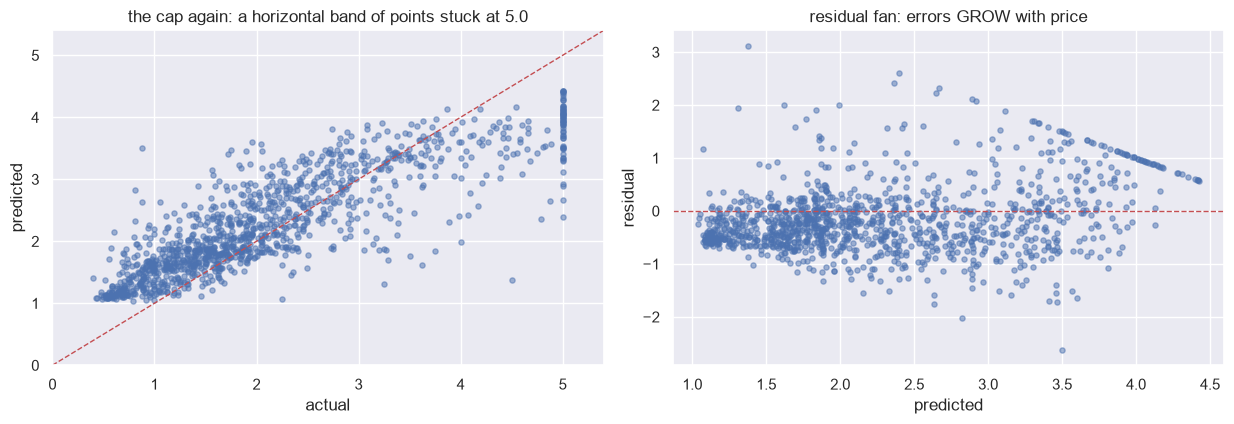

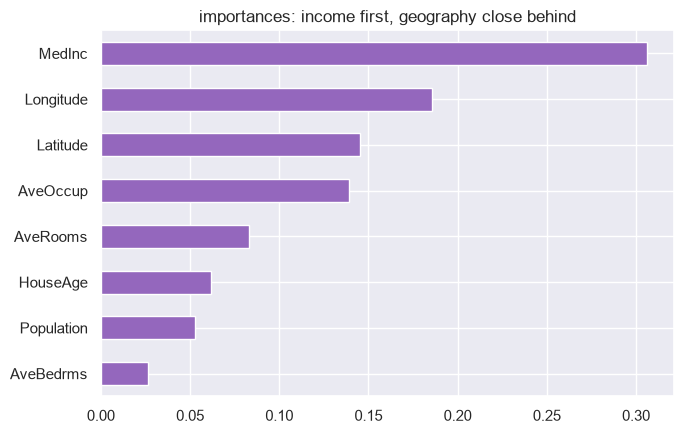

{'R²': 0.6840766235751076, 'MAE': 0.5129818151175118, 'RMSE': 0.6563825669338351}


In [8]:
final_pred = ada_full.predict(X_test)
resid = y_test - final_pred

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))
axes[0].scatter(y_test, final_pred, s=14, alpha=0.5)
lims = [0, 5.4]
axes[0].plot(lims, lims, "r--", lw=1)
axes[0].set_xlim(lims); axes[0].set_ylim(lims)
axes[0].set_xlabel("actual"); axes[0].set_ylabel("predicted")
axes[0].set_title("the cap again: a horizontal band of points stuck at 5.0")

axes[1].scatter(final_pred, resid, s=14, alpha=0.5)
axes[1].axhline(0, color="r", ls="--", lw=1)
axes[1].set_xlabel("predicted"); axes[1].set_ylabel("residual")
axes[1].set_title("residual fan: errors GROW with price")
plt.tight_layout(); plt.show()

imp = pd.Series(ada_full.feature_importances_, index=X.columns).sort_values()
imp.plot.barh(figsize=(7, 4.5), color="tab:purple")
plt.title("importances: income first, geography close behind")
plt.tight_layout(); plt.show()
print(metrics(y_test, final_pred))

### 7. Findings & limitations

**Findings**
- Boosting lifts R² well above single trees of the SAME depth-5 size; the sliced
  rounds curve shows most of the gain lands within the first couple hundred rounds,
  then plateaus.
- Learning-rate race: gentler steps (0.05-0.1) beat lr=0.2 - a good default posture
  for AdaBoost is small votes and many rounds.
- Median income is confirmed as the single dominant valuation feature, with
  latitude/longitude carrying the coastal premium.

**Limitations**
- ⚠️ **Capped target**: true prices above $500k were clipped to 5.00001 at the source,
  so expensive-segment errors are partly an artefact of the DATA, not the model.
- ⚠️ **No extrapolation** (demonstrated §5): never use this model outside the
  demographic range it was trained on - it will confidently return training-range
  numbers for a world that has moved on.
- Even at depth 5 the weak trees are weak: AdaBoost lags gradient boosting on this
  dataset - that gap motivates the next section.
- Early stopping silently shortens runs under `loss="linear"`; always report
  rounds survived.
- 6k-row sample of 20.6k blocks: results are stable but slightly pessimistic vs
  full-data fits.

### Summary takeaways

- One fit + a hand-rolled weighted-median slicer gives you the staged learning
  curve AdaBoost's regressor API refuses to provide.
- Verify any hand-rolled prediction rule against `model.predict()` before trusting it.
- Trees (and their ensembles) interpolate, they do not extrapolate - design your
  deployment boundary accordingly.